# Week 3 - Assignment 1
## EDA and Machine Learning on Agricultural Yield Dataset
**Name:** Prachi  
**Enrollment Number:** 04901022025  
**College:** Indira Gandhi Delhi Technical University For Women

In [2]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('agriculture_yield_dataset.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


## Part A: Understanding the Dataset

### Q1. Dataset Overview

In [3]:
# shape gives rows and columns count
def dataset_overview():
    rows, cols = df.shape
    print(f'Rows: {rows}')
    print(f'Columns: {cols}')
    print('\nColumn Names:')
    for col in df.columns:
        print('-', col)
    print('\nFirst 10 Records:')
    return df.head(10)

dataset_overview()

Rows: 1500
Columns: 8

Column Names:
- rainfall_mm
- temperature_c
- fertilizer_kg
- irrigation_hours
- soil_ph
- crop_type
- soil_type
- yield_ton_per_hectare

First 10 Records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


### Q2. Data Types and Missing Values

In [4]:
# dtypes shows data type, isnull().sum() shows missing values
def check_dtypes_missing():
    print('Data Types of Each Column:')
    print(df.dtypes)
    print('\nMissing Values per Column:')
    missing = df.isnull().sum()
    print(missing)
    if missing.sum() == 0:
        print('\nNo missing values found in the dataset.')
    else:
        print('\nColumns with missing values:', missing[missing > 0].index.tolist())

check_dtypes_missing()

Data Types of Each Column:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

Missing Values per Column:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No missing values found in the dataset.


### Q3. Descriptive Statistics

In [5]:
# describe() gives summary statistics for numerical columns
def descriptive_stats():
    stats = df.describe()
    print(stats)
    
    # finding highest mean and highest std feature
    highest_mean = stats.loc['mean'].idxmax()
    highest_std = stats.loc['std'].idxmax()
    print(f'\nFeature with highest mean: {highest_mean} ({stats.loc["mean", highest_mean]:.2f})')
    print(f'Feature with highest standard deviation: {highest_std} ({stats.loc["std", highest_std]:.2f})')

descriptive_stats()

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis

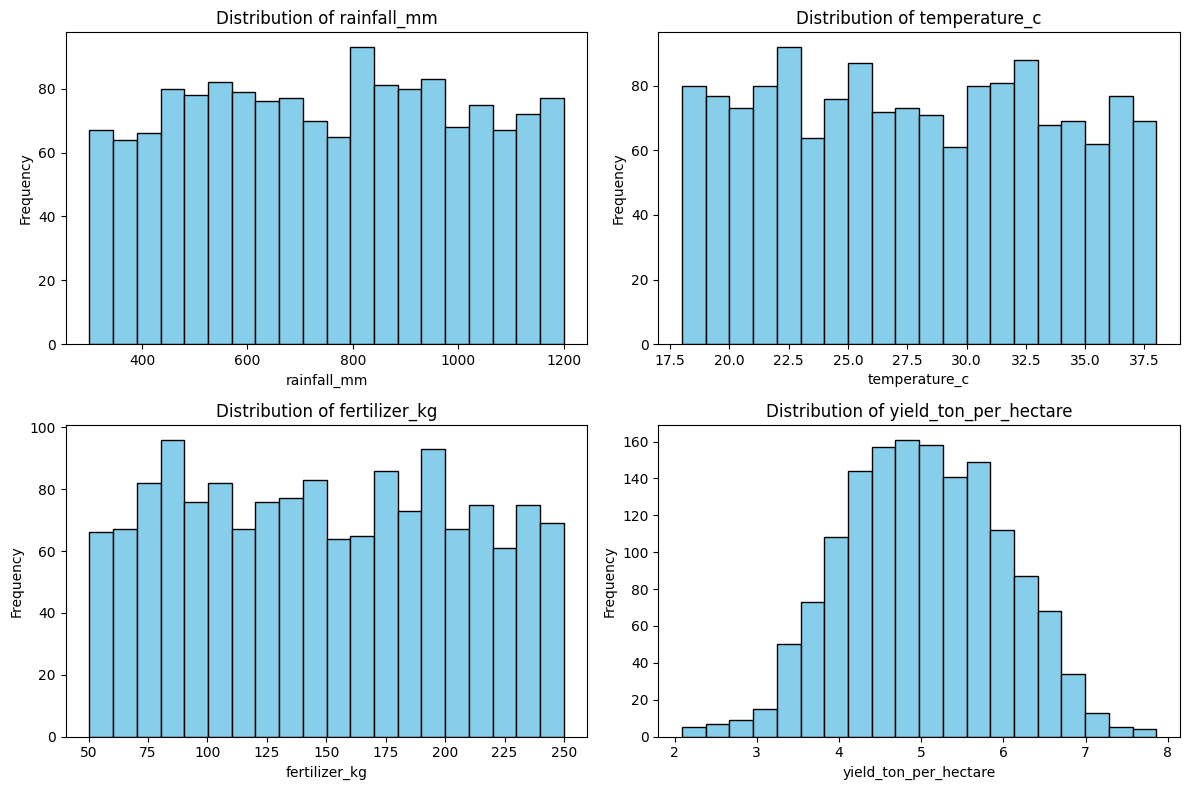

In [6]:
# histograms show the distribution shape of each feature
def plot_histograms():
    columns = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

plot_histograms()

**Observations:**

**rainfall_mm:**
1. Rainfall values are spread across a wide range
2. The distribution appears fairly spread out without extreme skew
3. Most values lie in the middle range

**temperature_c:**
1. Temperature is fairly evenly distributed
2. No major outliers are visible
3. Values mostly lie within a normal climate range

**fertilizer_kg:**
1. Fertilizer usage shows variation across records
2. Distribution looks roughly uniform
3. No extreme spikes observed

**yield_ton_per_hectare:**
1. Yield values cluster around a central range
2. Shape is close to a bell curve
3. Few values lie far from the center, indicating possible outliers

### Q5. Crop Type Analysis

Records per Crop Type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


C:\Users\samsung\AppData\Local\Temp\ipykernel_9088\350054067.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='crop_type', data=df, palette='Set2')


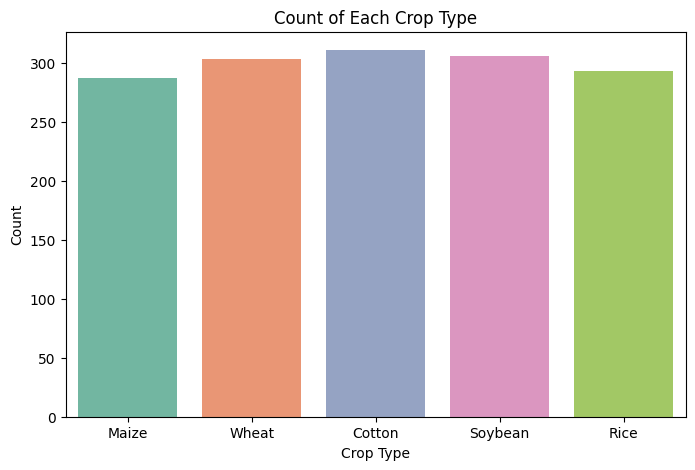


Most frequent crop: Cotton


In [7]:
# value_counts() counts records for each crop type
def crop_type_analysis():
    crop_counts = df['crop_type'].value_counts()
    print('Records per Crop Type:')
    print(crop_counts)
    
    # count plot for crop type
    plt.figure(figsize=(8, 5))
    sns.countplot(x='crop_type', data=df, palette='Set2')
    plt.title('Count of Each Crop Type')
    plt.xlabel('Crop Type')
    plt.ylabel('Count')
    plt.show()
    
    print(f'\nMost frequent crop: {crop_counts.idxmax()}')

crop_type_analysis()

### Q6. Soil Type Analysis

Frequency of Each Soil Type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


C:\Users\samsung\AppData\Local\Temp\ipykernel_9088\1800925448.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='soil_type', data=df, palette='Set3')


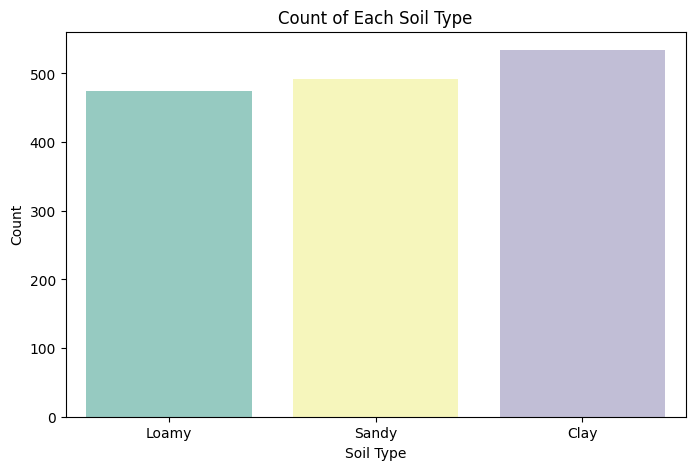


Most common soil type: Clay


In [8]:
# value_counts() counts frequency of each soil type
def soil_type_analysis():
    soil_counts = df['soil_type'].value_counts()
    print('Frequency of Each Soil Type:')
    print(soil_counts)
    
    # count plot for soil type
    plt.figure(figsize=(8, 5))
    sns.countplot(x='soil_type', data=df, palette='Set3')
    plt.title('Count of Each Soil Type')
    plt.xlabel('Soil Type')
    plt.ylabel('Count')
    plt.show()
    
    print(f'\nMost common soil type: {soil_counts.idxmax()}')

soil_type_analysis()

### Q7. Yield Distribution

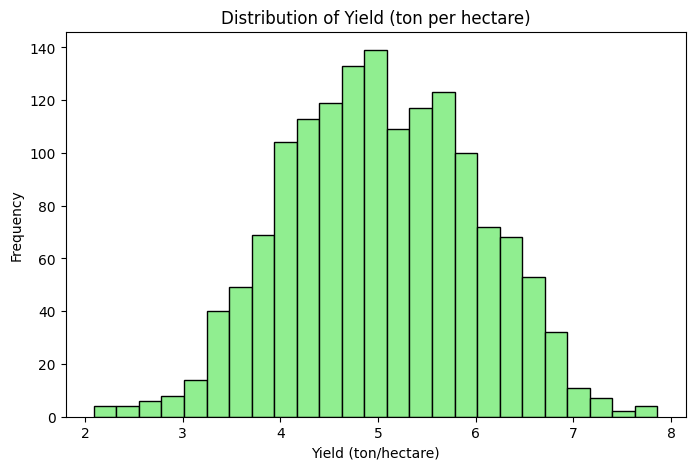

Skewness value: -0.001
The distribution is approximately normal.


In [9]:
# checking distribution shape and outliers using histogram
def yield_distribution():
    plt.figure(figsize=(8, 5))
    plt.hist(df['yield_ton_per_hectare'], bins=25, color='lightgreen', edgecolor='black')
    plt.title('Distribution of Yield (ton per hectare)')
    plt.xlabel('Yield (ton/hectare)')
    plt.ylabel('Frequency')
    plt.show()
    
    # checking skewness to see if normal
    skewness = df['yield_ton_per_hectare'].skew()
    print(f'Skewness value: {skewness:.3f}')
    
    if -0.5 <= skewness <= 0.5:
        print('The distribution is approximately normal.')
    else:
        print('The distribution is skewed, not perfectly normal.')

yield_distribution()

**Answer:**
- The yield distribution appears **approximately normal** (bell-shaped) based on the histogram and skewness value close to 0.
- There are a **few outliers** visible at the extreme ends of the histogram, but they are not very severe.

### Q8. Scatter Plot Analysis

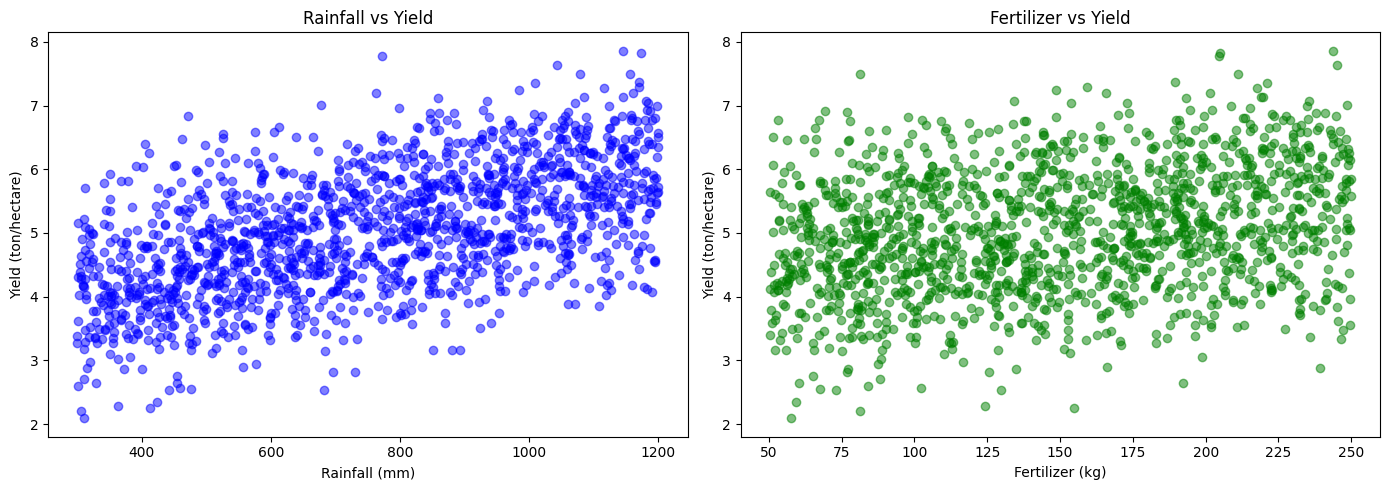

Rainfall vs Yield correlation: 0.554
Fertilizer vs Yield correlation: 0.278

Rainfall has a stronger relationship with yield.


In [10]:
# scatter plots show relationship between two variables
def scatter_plots():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # rainfall vs yield
    axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], color='blue', alpha=0.5)
    axes[0].set_title('Rainfall vs Yield')
    axes[0].set_xlabel('Rainfall (mm)')
    axes[0].set_ylabel('Yield (ton/hectare)')
    
    # fertilizer vs yield
    axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], color='green', alpha=0.5)
    axes[1].set_title('Fertilizer vs Yield')
    axes[1].set_xlabel('Fertilizer (kg)')
    axes[1].set_ylabel('Yield (ton/hectare)')
    
    plt.tight_layout()
    plt.show()
    
    # calculating correlation to compare strength
    rain_corr = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
    fert_corr = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
    print(f'Rainfall vs Yield correlation: {rain_corr:.3f}')
    print(f'Fertilizer vs Yield correlation: {fert_corr:.3f}')
    
    if abs(fert_corr) > abs(rain_corr):
        print('\nFertilizer has a stronger relationship with yield.')
    else:
        print('\nRainfall has a stronger relationship with yield.')

scatter_plots()

### Q9. Correlation Analysis

Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412    

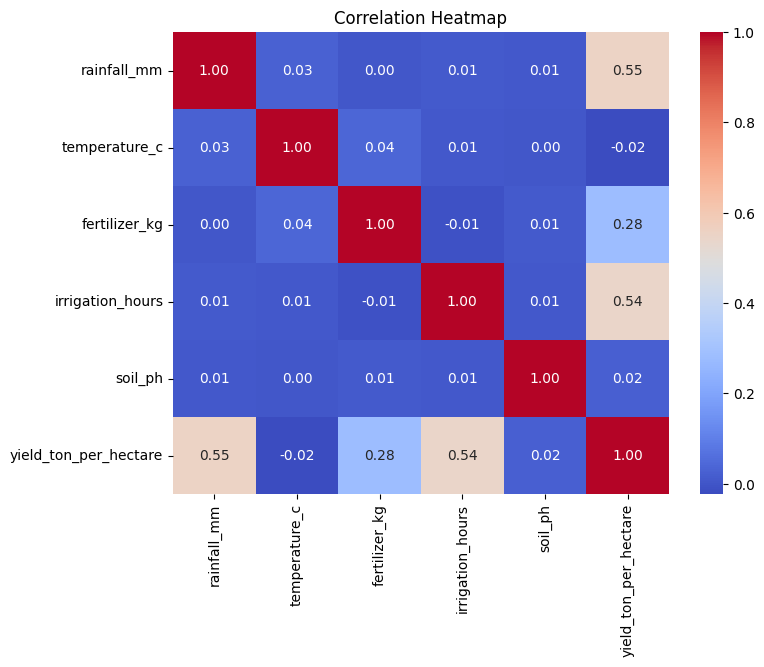


Top 3 features correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [11]:
# correlation matrix shows relationship between all numerical features
def correlation_analysis():
    numerical_df = df.select_dtypes(include=['float64', 'int64'])
    corr_matrix = numerical_df.corr()
    print('Correlation Matrix:')
    print(corr_matrix)
    
    # heatmap for visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()
    
    # finding top 3 features correlated with yield
    yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare')
    top3 = yield_corr.abs().sort_values(ascending=False).head(3)
    print('\nTop 3 features correlated with yield:')
    print(top3)

correlation_analysis()

### Q10. Group-Based Analysis

In [12]:
# groupby() calculates average yield per category
def group_analysis():
    crop_avg_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
    soil_avg_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
    
    print('Average Yield by Crop Type:')
    print(crop_avg_yield)
    print('\nAverage Yield by Soil Type:')
    print(soil_avg_yield)
    
    print(f'\nCrop with highest average yield: {crop_avg_yield.idxmax()} ({crop_avg_yield.max():.2f})')
    print(f'Soil type with highest average yield: {soil_avg_yield.idxmax()} ({soil_avg_yield.max():.2f})')

group_analysis()

Average Yield by Crop Type:
crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with highest average yield: Rice (5.49)
Soil type with highest average yield: Loamy (5.37)


## Part C: Data Preparation

### Q11. Feature Encoding

In [13]:
# One-Hot Encoding converts categories into separate 0/1 columns
def feature_encoding():
    global df_encoded
    
    # identifying categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print('Categorical Columns:', categorical_cols)
    
    # applying one-hot encoding
    df_encoded = pd.get_dummies(df, columns=categorical_cols)
    print('\nFirst 5 rows after One-Hot Encoding:')
    return df_encoded.head()

feature_encoding()

Categorical Columns: ['crop_type', 'soil_type']

First 5 rows after One-Hot Encoding:


C:\Users\samsung\AppData\Local\Temp\ipykernel_9088\845820052.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


### Q12. Feature Selection

In [14]:
# X = input features, y = target variable we want to predict
def feature_selection():
    global X, y
    
    # yield_ton_per_hectare is our target column
    X = df_encoded.drop('yield_ton_per_hectare', axis=1)
    y = df_encoded['yield_ton_per_hectare']
    
    print('Target Variable: yield_ton_per_hectare')
    print(f'Feature set X shape: {X.shape}')
    print(f'Target variable y shape: {y.shape}')

feature_selection()

Target Variable: yield_ton_per_hectare
Feature set X shape: (1500, 13)
Target variable y shape: (1500,)


## Part D: Machine Learning

### Q13. Train-Test Split

In [15]:
# 80% data for training, 20% for testing
def split_data():
    global X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print('Shape of X_train:', X_train.shape)
    print('Shape of X_test:', X_test.shape)
    print('Shape of y_train:', y_train.shape)
    print('Shape of y_test:', y_test.shape)

split_data()

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


### Q14. Linear Regression Model

In [16]:
# Linear Regression finds the best fit line for prediction
def train_linear_regression():
    global lr_model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    print('Model Coefficients:')
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
    print(coef_df)
    
    print(f'\nModel Intercept: {lr_model.intercept_:.4f}')
    
    # finding feature with highest positive coefficient
    highest_coef_feature = coef_df.loc[coef_df['Coefficient'].idxmax()]
    print(f'\nFeature with highest positive coefficient: {highest_coef_feature["Feature"]} ({highest_coef_feature["Coefficient"]:.4f})')

train_linear_regression()

Model Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280

Model Intercept: 1.9111

Feature with highest positive coefficient: crop_type_Rice (0.4774)
